In [3]:
import ast
import urllib.request
from pathlib import Path 

import cv2
import dlib
import IPython
import face_recognition
import numpy as np
import pandas as pd
import sqlalchemy as db
from tqdm import tqdm
from deepface import DeepFace
from qdrant_client import QdrantClient 
from qdrant_client.models import Distance, VectorParams, PointStruct
from qdrant_client.http import models
from retinaface import RetinaFace
from tmdbv3api import TMDb, TV, Find, Season, Episode, exceptions, Person

2025-01-25 12:49:38.683485: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [5]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [6]:
CLIENT = QdrantClient(host='192.168.0.131', port=6333)     

In [5]:
df = pd.read_csv('/home/amos/programs/CineFace/data/faces/house-md_2004_412142/House.MD.2004.S01E01.Everybody.Lies.1080p.BluRayRip.x265.10Bit.AC3.5.1-JATT.csv', index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_height,filepath,encoding,series_id,episode_id,season,episode,filename,distance_from_center,pct_of_frame
0,0.216,0.234,0.361,0.599,0.295,0.396,0.337,0.368,0.352,0.438,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,-0.181358\n0.104244\n0.0876662\n-0.0667203\n-0...,412142,NaN,1,1,House.MD.2004.S01E01.Everybody.Lies.1080p.BluR...,417.05,5.28
1,0.001,0.186,0.078,0.392,0.037,0.272,0.068,0.267,0.064,0.304,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,-0.0801143\n0.0317275\n0.05264\n-0.0311987\n-0...,412142,NaN,1,1,House.MD.2004.S01E01.Everybody.Lies.1080p.BluR...,913.90,1.57
2,0.404,0.205,0.537,0.562,0.475,0.355,0.506,0.330,0.523,0.400,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,-0.165783\n0.0656703\n0.0984607\n-0.0536536\n-...,412142,NaN,1,1,House.MD.2004.S01E01.Everybody.Lies.1080p.BluR...,138.29,4.73
3,0.188,0.165,0.275,0.377,0.235,0.249,0.265,0.250,0.263,0.281,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,-0.124113\n0.0551054\n0.11647\n-0.0238676\n-0....,412142,NaN,1,1,House.MD.2004.S01E01.Everybody.Lies.1080p.BluR...,572.50,1.84
4,0.042,0.121,0.108,0.288,0.075,0.187,0.099,0.188,0.098,0.210,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,-0.0924223\n0.0524208\n0.0978768\n-0.0616708\n...,412142,NaN,1,1,House.MD.2004.S01E01.Everybody.Lies.1080p.BluR...,876.50,1.09


In [6]:
encodings = df['encoding'].map(lambda x: dlib.vector(np.array([float(y) for y in x.split('\n')])))
encodings[0]

dlib.vector([-0.181358, 0.104244, 0.0876662, -0.0667203, -0.0884252, -0.0463296, -0.013924, -0.185655, 0.0435361, -0.0841954, 0.206233, -0.0618125, -0.239337, -0.0348063, -0.0492178, 0.185381, -0.156396, -0.159205, -0.1127, -0.0285497, 0.0221882, 0.0129683, 0.0161067, 0.0868135, -0.0654262, -0.310152, -0.0714962, -0.140916, -0.0283851, -0.0319459, -0.0234593, 0.0551106, -0.207063, -0.000820087, 0.0125293, 0.0271995, 0.00211452, -0.10946, 0.19917, -0.0552485, -0.228325, -0.0153942, 0.126337, 0.259226, 0.178281, -0.0331376, 0.000582084, -0.0302289, 0.0886054, -0.281332, 0.00817765, 0.117047, 0.116911, 0.0758737, 0.0234448, -0.183234, 0.109522, 0.104071, -0.196627, 0.0480048, 0.0441872, -0.123047, -0.0400318, -0.0498529, 0.272029, 0.14261, -0.103004, -0.109359, 0.16996, -0.121739, -0.0329618, 0.0471471, -0.176386, -0.204094, -0.224563, 0.0282091, 0.37593, 0.204473, -0.247497, 0.0430149, -0.131599, 0.0278391, 0.0635685, 0.068041, -0.0403429, -0.00863491, -0.114877, -0.00109064, 0.233111, -

In [7]:
labels = dlib.chinese_whispers_clustering(list(encodings), 0.35)

In [8]:
label_df = df.copy()
label_df['label'] = labels
cnt = label_df['label'].value_counts()
label_df = label_df.merge(cnt,
                          on='label')
label_df = label_df[label_df['count'] >= 5]
label_df['label'].value_counts()

label
7      709
188     61
96      56
872     52
431     43
      ... 
748      5
376      5
380      5
692      5
472      5
Name: count, Length: 92, dtype: int64

In [9]:
a = np.load('/home/amos/programs/FacesOfHomeland/data/encodings/S01E09_29712_0.npy')
a

array([-0.10231268,  0.06113989,  0.04225544, -0.0749239 , -0.05547281,
       -0.05445772,  0.03714282, -0.10504859,  0.17891592, -0.06322088,
        0.16085297,  0.00061048, -0.41108862, -0.05352367,  0.02473779,
        0.1498512 , -0.20641607, -0.22135264, -0.16712865, -0.05386597,
        0.02726993,  0.04221478,  0.0266422 ,  0.05018894, -0.15001565,
       -0.25021213, -0.05163651, -0.12034304, -0.00116553, -0.02294491,
        0.03868848,  0.10674604, -0.16499099,  0.0085279 ,  0.09023176,
        0.09114612, -0.03600483, -0.16797592,  0.29370299, -0.03459491,
       -0.22038627, -0.10341294,  0.04704552,  0.18072629,  0.23365185,
       -0.08135443,  0.03520926, -0.11211923,  0.17526789, -0.34479144,
        0.03763629,  0.22246958,  0.09759416,  0.07222322,  0.13762023,
       -0.26008043,  0.02592192,  0.23796931, -0.27092344,  0.03864755,
        0.01654626, -0.15185077, -0.05585284, -0.1160807 ,  0.18549493,
        0.07608972, -0.20691027, -0.1335994 ,  0.22553918, -0.15

In [10]:
df = pd.read_csv('/home/amos/programs/CineFace/data/faces/house-md_2004_412142/House.MD.2004.S01E07.Fidelity.1080p.BluRayRip.x265.10Bit.AC3.5.1-JATT.csv', index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_height,filepath,encoding,series_id,episode_id,season,episode,filename,distance_from_center,pct_of_frame
0,0.525,0.285,0.553,0.339,0.533,0.310,0.546,0.309,0.540,0.323,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[array([-0.07475564, 0.10480897, 0.00916628,...",412142,NaN,1,7,House.MD.2004.S01E07.Fidelity.1080p.BluRayRip....,217.01,0.15
1,0.462,0.260,0.489,0.320,0.479,0.285,0.485,0.285,0.485,0.298,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[array([-0.06302743, 0.10004357, 0.07669358,...",412142,NaN,1,7,House.MD.2004.S01E07.Fidelity.1080p.BluRayRip....,232.02,0.16
2,0.517,0.263,0.547,0.328,0.526,0.291,0.539,0.290,0.533,0.305,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[array([-0.05073253, 0.12925588, -0.02599236,...",412142,NaN,1,7,House.MD.2004.S01E07.Fidelity.1080p.BluRayRip....,229.26,0.19
3,0.369,0.291,0.398,0.355,0.378,0.313,0.391,0.315,0.384,0.326,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[array([-1.13506459e-01, 1.03429869e-01, 9.7...",412142,NaN,1,7,House.MD.2004.S01E07.Fidelity.1080p.BluRayRip....,295.03,0.18
4,0.587,0.257,0.620,0.334,0.596,0.285,0.610,0.287,0.602,0.299,...,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[array([-0.11725636, 0.04006988, -0.01880812,...",412142,NaN,1,7,House.MD.2004.S01E07.Fidelity.1080p.BluRayRip....,296.72,0.25


In [11]:
encoding_raw = df.at[0, 'encoding']
encoding_raw[1:-1]

'array([-0.07475564,  0.10480897,  0.00916628, -0.08303538, -0.08719322,\n       -0.05418926, -0.01473061, -0.0154367 ,  0.15420249,  0.00498593,\n        0.23012941,  0.02886567, -0.28392103, -0.1326831 ,  0.04401699,\n        0.11254545, -0.08933444, -0.07078099, -0.20999198, -0.11983111,\n       -0.03672809,  0.00972398, -0.00547564, -0.03988147, -0.11035223,\n       -0.19165182, -0.02541335, -0.12864752,  0.07388242, -0.16153759,\n        0.03652307,  0.00141393, -0.17766033, -0.14988297, -0.01309383,\n       -0.00284176, -0.04283465, -0.0522664 ,  0.16746059, -0.01523929,\n       -0.14631945, -0.03531545, -0.01415167,  0.22267663,  0.21132912,\n        0.01599327,  0.02427859, -0.06877099,  0.14981332, -0.29119822,\n        0.02990586,  0.12336539,  0.0708236 ,  0.09027702,  0.08674526,\n       -0.17704956,  0.05340558,  0.14140265, -0.22985058,  0.04792939,\n        0.05762631, -0.04135242, -0.11811639, -0.10372325,  0.1731658 ,\n        0.05249479, -0.10561414, -0.1396172 ,  0.1

In [12]:
ast.literal_eval(encoding_raw)

ValueError: malformed node or string on line 1: <ast.Call object at 0x76c9e21dfe80>

In [13]:
encodings = df['encoding'].map(lambda x: dlib.vector(np.array([float(y) for y in x.split('\n')])))
encodings[0]|

SyntaxError: invalid syntax (2334397816.py, line 2)

In [14]:
labels = dlib.chinese_whispers_clustering(list(encodings), 0.5)

In [15]:
label_df = df.copy()
label_df['label'] = labels
cnt = label_df['label'].value_counts()
label_df = label_df.merge(cnt,
                          on='label')
label_df = label_df[label_df['count'] >= 5]
label_df['label'].value_counts()

ValueError: Length of values (3176) does not match length of index (3751)

In [16]:
df = pd.read_csv('../../data/test.csv', index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_right_y,mouth_left_x,mouth_left_y,confidence,face_num,frame_num,img_width,img_height,filepath,encoding
0,0.216,0.234,0.361,0.599,0.295,0.396,0.337,0.368,0.352,0.438,...,0.524,0.353,0.502,0.999,0,192,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-1.04528122e-01,4.26750705e-02,9.92560610e-02..."
1,0.001,0.186,0.078,0.392,0.037,0.272,0.068,0.267,0.064,0.304,...,0.345,0.068,0.342,0.997,1,192,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-1.09764203e-01,1.01907797e-01,4.41615433e-02..."
2,0.404,0.205,0.537,0.562,0.475,0.355,0.506,0.330,0.523,0.400,...,0.486,0.527,0.467,0.999,0,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.10503129,0.02722587,0.11773209,-0.02752084..."
3,0.188,0.165,0.275,0.377,0.235,0.249,0.265,0.250,0.263,0.281,...,0.326,0.265,0.327,0.999,1,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.17259115,0.08089909,0.09485973,-0.01292775..."
4,0.042,0.121,0.108,0.288,0.075,0.187,0.099,0.188,0.098,0.210,...,0.246,0.099,0.248,0.998,2,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.19313513,0.11090928,0.06218918,-0.07306869..."


In [17]:
encodings = [dlib.vector(np.array(ast.literal_eval(x))) for x in df['encoding']]

In [18]:
encodings[0]

dlib.vector([-0.104528, 0.0426751, 0.0992561, -0.0593646, -0.149049, -0.0127676, -0.0180688, -0.138285, 0.141519, -0.0864197, 0.175082, -0.0319806, -0.129515, -0.00317135, -0.127852, 0.121104, -0.134168, -0.180152, -0.0262231, -0.0128628, 0.00962348, 0.0399436, -0.00190442, 0.0777198, -0.0848087, -0.297484, -0.0712202, -0.0848369, 0.085191, -0.085398, -0.0410938, 0.0798164, -0.235971, -0.0347618, 0.0197349, 0.0672866, -0.0135622, -0.152344, 0.208007, 0.0252981, -0.289711, -0.0344354, 0.0896748, 0.265736, 0.181654, -0.0649052, -0.0380217, -0.0373152, 0.177467, -0.226729, 0.0224802, 0.136354, 0.141564, 0.0563762, -0.00723511, -0.121692, 0.0914861, 0.103403, -0.192785, 0.0253741, 0.0634957, -0.0946529, 0.0682621, -0.0397877, 0.149093, 0.0982512, -0.0106462, -0.147227, 0.13126, -0.15592, -0.0103594, 0.132248, -0.132608, -0.169618, -0.196896, 0.0106021, 0.474463, 0.189124, -0.0885544, 0.0445525, -0.0744193, -0.0482942, 0.0549523, 0.0804658, -0.0729555, 0.0574547, -0.0786873, 0.0615506, 0.27

In [19]:
labels = dlib.chinese_whispers_clustering(list(encodings), 0.5)

In [20]:
label_df = df.copy()
label_df['label'] = labels
cnt = label_df['label'].value_counts()
label_df = label_df.merge(cnt,
                          on='label')
label_df = label_df[label_df['count'] >= 5]
label_df['label'].value_counts()

label
1     1309
12     700
3      245
15     212
16     168
2      152
14     150
13      98
5       31
6       25
7       18
21      16
25      14
28       7
9        6
27       5
Name: count, dtype: int64

In [21]:
label_df.to_csv('../../data/labels.csv')

In [34]:
CLIENT.recreate_collection(collection_name='House',
                                   vectors_config=VectorParams(size=128, distance=Distance.COSINE))

True

In [53]:
points = [models.PointStruct(
    id=idx,
    payload={
        **row.to_dict()
    },
    vector=np.array(ast.literal_eval(row['encoding']))
) for idx, row in df.iterrows()]

In [54]:
CLIENT.upsert(
    collection_name='House',
    points=points
)

UpdateResult(operation_id=1, status=<UpdateStatus.COMPLETED: 'completed'>)

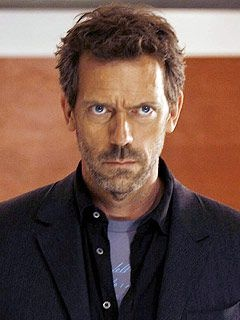

In [26]:
house_test = cv2.imread('./images/house_test.jpg')
show_image(house_test)

2025-01-19 12:55:43.001735: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-19 12:55:43.006124: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-19 12:55:43.006300: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

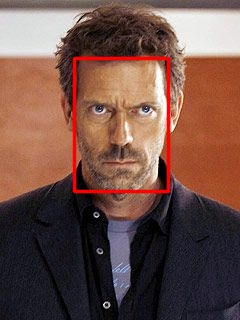

In [27]:
faces = RetinaFace.detect_faces(house_test)
draw_faces(house_test, faces)

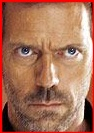

74 58 168 191


In [28]:
x1, y1, x2, y2 = faces['face_1']['facial_area']
face = house_test[y1:y2, x1:x2]
show_image(face)
print(x1, y1, x2, y2)

In [29]:
rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
h, w = rgb.shape[:2]
e = face_recognition.face_encodings(rgb, known_face_locations=[[0, w, h, 0]])
e

[array([-0.1285325 ,  0.09716588,  0.05518114, -0.0824948 , -0.09102411,
        -0.01936165,  0.01464153, -0.04873521,  0.13092807,  0.02218405,
         0.18983302,  0.09165947, -0.24975307, -0.11034152, -0.0081673 ,
         0.05023995, -0.15716314, -0.12471022, -0.15135688, -0.0043348 ,
         0.06956051,  0.10365357, -0.03379964,  0.02029568, -0.12014508,
        -0.24245241, -0.10220454, -0.13851635,  0.02254018, -0.21152554,
         0.05082726, -0.09038101, -0.14479351, -0.11451725, -0.01556131,
         0.01250526, -0.06867921, -0.15315422,  0.23340878, -0.03367119,
        -0.17879821,  0.02947033,  0.04826847,  0.32127497,  0.14065425,
        -0.07805089,  0.03463408, -0.00709962,  0.11390603, -0.33217582,
         0.06220993,  0.12409445,  0.09495531,  0.09000666,  0.1354361 ,
        -0.15153822,  0.05260265,  0.16504891, -0.24735126,  0.17321326,
         0.02684114, -0.17361796,  0.02950128, -0.00294992,  0.17301965,
         0.08287904, -0.11268681, -0.1409443 ,  0.0

In [78]:
CLIENT.recreate_collection(collection_name='Headshots_512',
                                   vectors_config=VectorParams(size=512, distance=Distance.COSINE))

True

In [87]:
headshot_dir = Path('./images')
files = [x for x in headshot_dir.iterdir()]
for num, file in enumerate(files):
    img = cv2.imread(str(file))
    faces = RetinaFace.detect_faces(img)
    x1, y1, x2, y2 = faces['face_1']['facial_area']
    face = img[y1:y2, x1:x2]
    rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    encoding = DeepFace.represent(face, 
                                  model_name='Facenet512', 
                                  detector_backend='skip', 
                                  enforce_detection=False,
                                  normalization='Facenet2018',
                                  max_faces=1,
                                  align=True)
    # e = face_recognition.face_encodings(rgb, known_face_locations=[[0, w, h, 0]])
    point = models.PointStruct(id=num,
                               payload={'name': file.stem},
                               vector=e[0])
    CLIENT.upsert(collection_name='Headshots_512',
                  points=[point])

In [65]:
response = CLIENT.query_points(
    collection_name='House',
    query=e[0],
    limit=df.shape[0]
)

In [66]:
response.points

[ScoredPoint(id=2355, version=1, score=0.9626357, payload={'x1': 0.302, 'y1': 0.256, 'x2': 0.479, 'y2': 0.623, 'right_eye_x': 0.33, 'right_eye_y': 0.426, 'left_eye_x': 0.4, 'left_eye_y': 0.397, 'nose_x': 0.362, 'nose_y': 0.505, 'mouth_right_x': 0.37, 'mouth_right_y': 0.568, 'mouth_left_x': 0.416, 'mouth_left_y': 0.543, 'confidence': 1.0, 'face_num': 0, 'frame_num': 45096, 'img_width': 1920, 'img_height': 1080, 'filepath': '/home/amos/media/tv/House.MD.2004.S01-08.1080p.BluRayRip.x265.10Bit.AC3.5.1-JATT/Season 1/House.MD.2004.S01E01.Everybody.Lies.1080p.BluRayRip.x265.10Bit.AC3.5.1-JATT.mkv', 'encoding': '[-0.09369465,0.11443993,0.04903032,-0.01732613,-0.11397658,-0.0243549,-0.05668245,-0.08248618,0.06228066,0.00790037,0.19702485,0.04536421,-0.23931974,-0.03679614,-0.04419078,0.05281335,-0.16991119,-0.10004471,-0.13880476,-0.03811714,0.062761,0.10388458,-0.01023379,0.06802776,-0.12043781,-0.22613746,-0.03631065,-0.12966034,0.01732952,-0.19078149,-0.00749976,-0.08940994,-0.19987996,-0.08

In [77]:
response_df = pd.DataFrame([{**x.payload, 'score': x.score} for x in response.points])
response_df.sort_values(by='score')
response_df.tail()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_left_x,mouth_left_y,confidence,face_num,frame_num,img_width,img_height,filepath,encoding,score
3171,0.367,0.132,0.510,0.475,0.420,0.275,0.486,0.289,0.458,0.342,...,0.471,0.407,1.000,0,41904,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.12198669,0.10877811,0.13841349,0.00067269,...",0.786975
3172,0.715,0.244,0.764,0.371,0.722,0.297,0.729,0.298,0.716,0.319,...,0.730,0.342,0.998,0,18504,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.1072392,0.03635912,0.1197582,-0.04855334,-...",0.785735
3173,0.614,0.220,0.725,0.481,0.642,0.327,0.695,0.340,0.663,0.392,...,0.687,0.421,1.000,0,1560,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.17318991,0.09094041,0.07518869,-0.0980795,...",0.785187
3174,0.528,0.106,0.626,0.346,0.545,0.209,0.589,0.217,0.558,0.263,...,0.587,0.289,1.000,0,60408,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.11656421,0.03930114,0.0879176,-0.08465353,...",0.772557
3175,0.729,0.000,0.854,0.213,0.755,0.063,0.815,0.054,0.782,0.102,...,0.816,0.141,1.000,1,60408,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.11956242,0.00069578,0.02237007,-0.07169007...",0.749090


In [68]:
cap = cv2.VideoCapture(df.at[0, 'filepath'])

In [70]:
dst = Path('/home/amos/datasets/CineFace/images/house/S01E01/house')
for idx, row in tqdm(response_df.iterrows(), total=response_df.shape[0]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    x1 = int(row['x1'] * row['img_width'])
    y1 = int(row['y1'] * row['img_height'])
    x2 = int(row['x2'] * row['img_width'])
    y2 = int(row['y2'] * row['img_height'])
    face = frame[y1:y2, x1:x2]
    name = f'{row["frame_num"]}_{row["face_num"]}.png'
    fp = dst.joinpath(name)
    cv2.imwrite(str(fp), face)

  0%|          | 0/3176 [00:00<?, ?it/s]

 29%|██▊       | 909/3176 [03:27<08:37,  4.38it/s]


KeyboardInterrupt: 

In [96]:
data = []
for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
    v = np.array(ast.literal_eval(row['encoding']))
    response = CLIENT.query_points(collection_name='Headshots',
                                   query=v,
                                   limit=6)
    response_df = pd.DataFrame([{**x.payload, 'score': x.score} for x in response.points])
    response_df = response_df.sort_values(by='score')
    name = response_df.at[0, 'name']
    row['name'] = name 
    data.append(row)
result_df = pd.DataFrame(data)
result_df.head()

100%|██████████| 3176/3176 [00:28<00:00, 112.39it/s]


,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,mouth_left_x,mouth_left_y,confidence,face_num,frame_num,img_width,img_height,filepath,encoding,name
0,0.216,0.234,0.361,0.599,0.295,0.396,0.337,0.368,0.352,0.438,...,0.353,0.502,0.999,0,192,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-1.04528122e-01,4.26750705e-02,9.92560610e-02...",cameron
1,0.001,0.186,0.078,0.392,0.037,0.272,0.068,0.267,0.064,0.304,...,0.068,0.342,0.997,1,192,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-1.09764203e-01,1.01907797e-01,4.41615433e-02...",house_test
2,0.404,0.205,0.537,0.562,0.475,0.355,0.506,0.330,0.523,0.400,...,0.527,0.467,0.999,0,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.10503129,0.02722587,0.11773209,-0.02752084...",cuddy
3,0.188,0.165,0.275,0.377,0.235,0.249,0.265,0.250,0.263,0.281,...,0.265,0.327,0.999,1,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.17259115,0.08089909,0.09485973,-0.01292775...",house_test
4,0.042,0.121,0.108,0.288,0.075,0.187,0.099,0.188,0.098,0.210,...,0.099,0.248,0.998,2,216,1920,1080,/home/amos/media/tv/House.MD.2004.S01-08.1080p...,"[-0.19313513,0.11090928,0.06218918,-0.07306869...",cameron


In [100]:
dst = Path('/home/amos/datasets/CineFace/images/house/S01E01/')
cap = cv2.VideoCapture(result_df.at[0, 'filepath'])
for idx, row in tqdm(result_df.iterrows(), total=result_df.shape[0]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    x1 = int(row['x1'] * row['img_width'])
    y1 = int(row['y1'] * row['img_height'])
    x2 = int(row['x2'] * row['img_width'])
    y2 = int(row['y2'] * row['img_height'])
    face = frame[y1:y2, x1:x2]
    dst_dir = dst.joinpath(row['name'])
    if not dst_dir.exists():
        Path.mkdir(dst_dir)
    fp = dst_dir.joinpath(f'{row["frame_num"]}_{row["face_num"]}.jpg')
    cv2.imwrite(str(fp), face)    




















































































































































































100%|██████████| 3176/3176 [12:37<00:00,  4.19it/s]


In [7]:
tmdb = TMDb()
tmdb.api_key = '64a6b6f9419ae4cba5b9a5f1c9e87401'

In [103]:
episode = Episode()

In [114]:
e = episode.details(1408, 1, 1)
e.keys()

dict_keys(['air_date', 'crew', 'episode_number', 'guest_stars', 'name', 'overview', 'id', 'production_code', 'runtime', 'season_number', 'still_path', 'vote_average', 'vote_count', 'images', 'translations'])

In [117]:
[x for x in e['guest_stars']]

[{'character': 'Rebecca Adler', 'credit_id': '5256cc5219c2956ff6070e9a', 'order': 508, 'adult': False, 'gender': 1, 'id': 17346, 'known_for_department': 'Acting', 'name': 'Robin Tunney', 'original_name': 'Robin Tunney', 'popularity': 26.148, 'profile_path': '/6Q41n1HfbEo8lOK0eXGNtZMeP4n.jpg'},
 {'character': 'Orange Colored Patient', 'credit_id': '5256cc5219c2956ff6070ede', 'order': 580, 'adult': False, 'gender': 2, 'id': 41436, 'known_for_department': 'Acting', 'name': 'Andrew Airlie', 'original_name': 'Andrew Airlie', 'popularity': 7.01, 'profile_path': '/ksxnvf68ohto7VWO4eE3VgTQAuc.jpg'},
 {'character': 'Melanie Landon', 'credit_id': '5d0f1a46c3a3681682243fed', 'order': 852, 'adult': False, 'gender': 1, 'id': 62717, 'known_for_department': 'Acting', 'name': 'Rekha Sharma', 'original_name': 'Rekha Sharma', 'popularity': 10.037, 'profile_path': '/3qLo8UbKs26n7g1oyKHckNH1IvU.jpg'},
 {'character': 'Sydney', 'credit_id': '5d0f1a6bc3a3682f6822d021', 'order': 853, 'adult': False, 'gender':

In [119]:
[x for x in e['crew']]

[{'department': 'Writing', 'job': 'Writer', 'credit_id': '5256cc5219c2956ff6070f0e', 'adult': False, 'gender': 2, 'id': 169061, 'known_for_department': 'Writing', 'name': 'David Shore', 'original_name': 'David Shore', 'popularity': 8.298, 'profile_path': '/5xVWN3KCGtGjGkEIrHqHrx8UikG.jpg'},
 {'department': 'Directing', 'job': 'Director', 'credit_id': '5256cc5219c2956ff6070f76', 'adult': False, 'gender': 2, 'id': 9032, 'known_for_department': 'Directing', 'name': 'Bryan Singer', 'original_name': 'Bryan Singer', 'popularity': 5.906, 'profile_path': '/to8mWJabPoWkphkbYKoutCVSj06.jpg'},
 {'job': 'Co-Producer', 'department': 'Production', 'credit_id': '570d646a9251413996000c61', 'adult': False, 'gender': 0, 'id': 1227669, 'known_for_department': 'Production', 'name': 'Todd London', 'original_name': 'Todd London', 'popularity': 0.764, 'profile_path': None},
 {'job': 'Original Music Composer', 'department': 'Sound', 'credit_id': '570d7193c3a368734c00018e', 'adult': False, 'gender': 0, 'id': 1

In [120]:
[print(k, v) for k, v in e.items()]

air_date 2004-11-16
crew [{'department': 'Writing', 'job': 'Writer', 'credit_id': '5256cc5219c2956ff6070f0e', 'adult': False, 'gender': 2, 'id': 169061, 'known_for_department': 'Writing', 'name': 'David Shore', 'original_name': 'David Shore', 'popularity': 8.298, 'profile_path': '/5xVWN3KCGtGjGkEIrHqHrx8UikG.jpg'}, {'department': 'Directing', 'job': 'Director', 'credit_id': '5256cc5219c2956ff6070f76', 'adult': False, 'gender': 2, 'id': 9032, 'known_for_department': 'Directing', 'name': 'Bryan Singer', 'original_name': 'Bryan Singer', 'popularity': 5.906, 'profile_path': '/to8mWJabPoWkphkbYKoutCVSj06.jpg'}, {'job': 'Co-Producer', 'department': 'Production', 'credit_id': '570d646a9251413996000c61', 'adult': False, 'gender': 0, 'id': 1227669, 'known_for_department': 'Production', 'name': 'Todd London', 'original_name': 'Todd London', 'popularity': 0.764, 'profile_path': None}, {'job': 'Original Music Composer', 'department': 'Sound', 'credit_id': '570d7193c3a368734c00018e', 'adult': False

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [8]:
season = Season()

In [9]:
s = season.details(1408, 1)
s

{'air_date': '2004-11-16', 'episodes': [{'air_date': '2004-11-16', 'episode_number': 1, 'episode_type': 'standard', 'id': 63738, 'name': 'Pilot', 'overview': 'Dr. Gregory House, a brilliant diagnostician but devoid of bedside  manner, and his elite team of young medical experts rush to save the  life of a kindergarten teacher who started  speaking gibberish and passed out in front of her class.', 'production_code': 'HOU-101', 'runtime': 44, 'season_number': 1, 'show_id': 1408, 'still_path': '/zPQe0nh81i8rTpJej8IAAIBo48i.jpg', 'vote_average': 7.8, 'vote_count': 59, 'crew': [{'department': 'Writing', 'job': 'Writer', 'credit_id': '5256cc5219c2956ff6070f0e', 'adult': False, 'gender': 2, 'id': 169061, 'known_for_department': 'Writing', 'name': 'David Shore', 'original_name': 'David Shore', 'popularity': 6.261, 'profile_path': '/5xVWN3KCGtGjGkEIrHqHrx8UikG.jpg'}, {'department': 'Directing', 'job': 'Director', 'credit_id': '5256cc5219c2956ff6070f76', 'adult': False, 'gender': 2, 'id': 9032, 

In [138]:
[print(k, v) for k, v in s.items()]

air_date 2008-09-16
episodes [{'air_date': '2008-09-16', 'episode_number': 1, 'episode_type': 'standard', 'id': 63784, 'name': 'Dying Changes Everything', 'overview': 'In the aftermath of personal tragedy, Wilson resigns from the hospital... and from his friendship with House. Meanwhile, Thirteen struggles with her personal medical problems while helping treat an executive assistant with a similar situation to her own.', 'production_code': '', 'runtime': 44, 'season_number': 5, 'show_id': 1408, 'still_path': '/2n1GDaKtXmaGY35Zij7SUgCraZj.jpg', 'vote_average': 7.677, 'vote_count': 31, 'crew': [{'department': 'Directing', 'job': 'Director', 'credit_id': '5256cc7419c2956ff60730e5', 'adult': False, 'gender': 2, 'id': 45645, 'known_for_department': 'Directing', 'name': 'Deran Sarafian', 'original_name': 'Deran Sarafian', 'popularity': 2.732, 'profile_path': None}, {'department': 'Writing', 'job': 'Writer', 'credit_id': '5256cc9219c2956ff607536b', 'adult': False, 'gender': 2, 'id': 1219508, 

[None, None, None, None, None, None, None, None, None, None, None, None]

In [10]:
[x for x in s['credits']['cast']]

[{'adult': False, 'gender': 2, 'id': 41419, 'known_for_department': 'Acting', 'name': 'Hugh Laurie', 'original_name': 'Hugh Laurie', 'popularity': 40.225, 'profile_path': '/akArncggHnusP5jxzMBKmJDRrMo.jpg', 'character': 'Gregory House', 'credit_id': '5256ccf519c2956ff607ca00', 'order': 0},
 {'adult': False, 'gender': 1, 'id': 41420, 'known_for_department': 'Acting', 'name': 'Lisa Edelstein', 'original_name': 'Lisa Edelstein', 'popularity': 26.068, 'profile_path': '/wWNU2koV7qksXLtXDtbuGcbnfa1.jpg', 'character': 'Lisa Cuddy', 'credit_id': '5256ccf519c2956ff607cbc4', 'order': 1},
 {'adult': False, 'gender': 2, 'id': 2692, 'known_for_department': 'Acting', 'name': 'Robert Sean Leonard', 'original_name': 'Robert Sean Leonard', 'popularity': 29.354, 'profile_path': '/jXehZM0AWLJ2OIz4o0jFtHEzcMI.jpg', 'character': 'James Wilson', 'credit_id': '5256ccf519c2956ff607cb72', 'order': 2},
 {'adult': False, 'gender': 2, 'id': 4987, 'known_for_department': 'Acting', 'name': 'Omar Epps', 'original_na

In [142]:
person = Person()

In [145]:
p = person.details(41419)
[print(k, v) for k, v in p.items()]

adult False
also_known_as ['James Hugh Calum Laurie', 'ヒュー・ローリー', '휴 로리', 'Хʼю Лорі']
biography James Hugh Calum Laurie CBE is an English actor, director, singer, musician, comedian, and author. He is known for portraying the title character on the Fox medical drama series House (2004–2012), for which he received two Golden Globe Awards and nominations for numerous other awards. He was listed in the 2011 Guinness World Records as the most watched leading man on television and was one of the highest-paid actors in a television drama, earning £250,000 ($409,000) per episode of House.

His other television credits include arms dealer Richard Onslow Roper in the miniseries The Night Manager (2016), for which he won his third Golden Globe Award, and Senator Tom James in the HBO sitcom Veep (2012–2019), for which he received his 10th Emmy Award nomination.

Forced to abandon rowing during a bout of glandular fever, he joined the Cambridge Footlights, a university dramatic club that has produ

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [146]:
p['images']

{'profiles': [{'aspect_ratio': 0.667, 'height': 2849, 'iso_639_1': None, 'file_path': '/akArncggHnusP5jxzMBKmJDRrMo.jpg', 'vote_average': 1.75, 'vote_count': 4, 'width': 1900}, {'aspect_ratio': 0.667, 'height': 721, 'iso_639_1': None, 'file_path': '/lpu443aKW5aKzVnV4xjiqvD1DnK.jpg', 'vote_average': 1.75, 'vote_count': 4, 'width': 481}]}

In [156]:
url = p['images']['profiles'][1]['file_path']
url

'/lpu443aKW5aKzVnV4xjiqvD1DnK.jpg'

In [157]:
r = urllib.request.urlopen(f'http://image.tmdb.org/t/p/w500{url}')

In [158]:
img_array = np.array(bytearray(r.read()), dtype=np.uint8)
img = cv2.imdecode(img_array, -1)

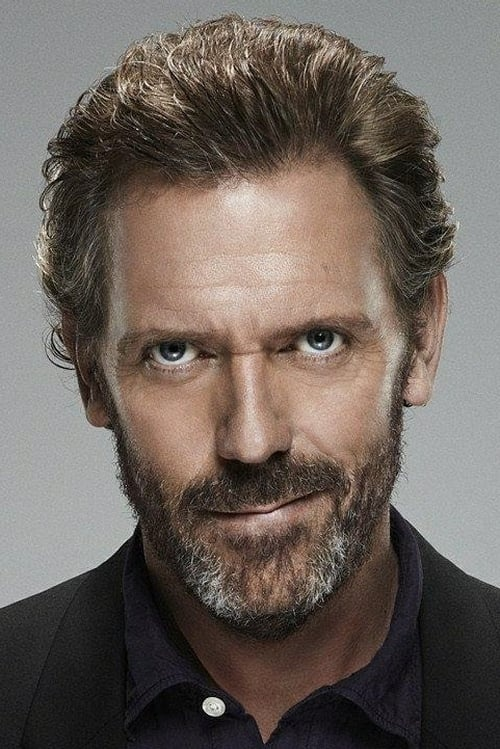

In [159]:
show_image(img)